# 1. Import Libraries

In [1]:

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
import os
from scipy.stats import zscore
from sklearn.preprocessing import MinMaxScaler , StandardScaler , RobustScaler
from sklearn.decomposition import PCA
from utils.constant import Constant
import warnings
warnings.filterwarnings('ignore')

CONSTANT = Constant()

# 1. Load and Examine the Dataset

In [2]:
print("Loading dataset...")
# Create column names
columns = ['class_label']
for i in range(21):
    columns += [f'landmark_{i}_x', f'landmark_{i}_y']

Loading dataset...


In [3]:
df = pd.read_csv('model/keypoint_classifier/gesture_3/keypoint.csv', header=None, names=columns)

In [4]:
print(f"Dataset shape: {df.shape}")
print("\nFirst 5 rows:")
print(df.head())

Dataset shape: (74552, 43)

First 5 rows:
   class_label  landmark_0_x  landmark_0_y  landmark_1_x  landmark_1_y  \
0            0           437           378           472           342   
1            0           332           264           276           224   
2            0           440           384           474           350   
3            0           447           265           422           243   
4            0           397           250           348           202   

   landmark_2_x  landmark_2_y  landmark_3_x  landmark_3_y  landmark_4_x  ...  \
0           489           304           472           276           449  ...   
1           249           183           247           160           261  ...   
2           491           313           478           284           456  ...   
3           410           209           403           178           389  ...   
4           332           157           349           130           376  ...   

   landmark_16_x  landmark_16_y 

In [5]:
# 2. Basic Data Exploration
print("\n\nBasic statistics:")
print(df.describe())



Basic statistics:
        class_label  landmark_0_x  landmark_0_y  landmark_1_x  landmark_1_y  \
count  74552.000000  74552.000000  74552.000000  74552.000000  74552.000000   
mean       2.014419    313.634108    340.420955    313.354477    315.266673   
std        1.387438    107.560029     68.198120    103.846552     68.380700   
min        0.000000     32.000000     83.000000     26.000000     41.000000   
25%        1.000000    226.000000    295.000000    230.000000    271.000000   
50%        2.000000    316.000000    345.000000    318.000000    319.000000   
75%        3.000000    404.000000    389.000000    397.000000    363.000000   
max        4.000000    614.000000    526.000000    610.000000    514.000000   

       landmark_2_x  landmark_2_y  landmark_3_x  landmark_3_y  landmark_4_x  \
count  74552.000000  74552.000000  74552.000000  74552.000000  74552.000000   
mean     313.701121    279.607308    314.799979    254.051387    316.511737   
std      103.095822     69.1801

In [6]:
# Check for nulls in each column
null_counts = df.isnull().sum()
print("\nNull values per column:")
print(null_counts)


Null values per column:
class_label      0
landmark_0_x     0
landmark_0_y     0
landmark_1_x     0
landmark_1_y     0
landmark_2_x     0
landmark_2_y     0
landmark_3_x     0
landmark_3_y     0
landmark_4_x     0
landmark_4_y     0
landmark_5_x     0
landmark_5_y     0
landmark_6_x     0
landmark_6_y     0
landmark_7_x     0
landmark_7_y     0
landmark_8_x     0
landmark_8_y     0
landmark_9_x     0
landmark_9_y     0
landmark_10_x    0
landmark_10_y    0
landmark_11_x    0
landmark_11_y    0
landmark_12_x    0
landmark_12_y    0
landmark_13_x    0
landmark_13_y    0
landmark_14_x    0
landmark_14_y    0
landmark_15_x    0
landmark_15_y    0
landmark_16_x    0
landmark_16_y    0
landmark_17_x    0
landmark_17_y    0
landmark_18_x    0
landmark_18_y    0
landmark_19_x    0
landmark_19_y    0
landmark_20_x    0
landmark_20_y    0
dtype: int64


In [7]:
# Check if any nulls at all
if df.isnull().values.any():
    print("⚠️ There are missing (null) values in the DataFrame.")
else:
    print("✅ No missing (null) values found.")

✅ No missing (null) values found.


In [8]:
# Count duplicate rows
duplicate_count = df.duplicated().sum()
print(f"\nNumber of duplicate rows: {duplicate_count}")

if duplicate_count > 0:
    print("Sample of duplicate rows:")
    duplicates = df[df.duplicated()]
    print(duplicates.head())
    
    # Remove duplicates
    df = df.drop_duplicates()
    print(f"DataFrame shape after dropping duplicates: {df.shape}")


Number of duplicate rows: 0


In [9]:
# 3. Class Distribution Analysis
print("\nClass distribution:")
class_distribution = df['class_label'].value_counts().sort_index()
print(class_distribution)


Class distribution:
class_label
0    15135
1    12473
2    16473
3    17124
4    13347
Name: count, dtype: int64


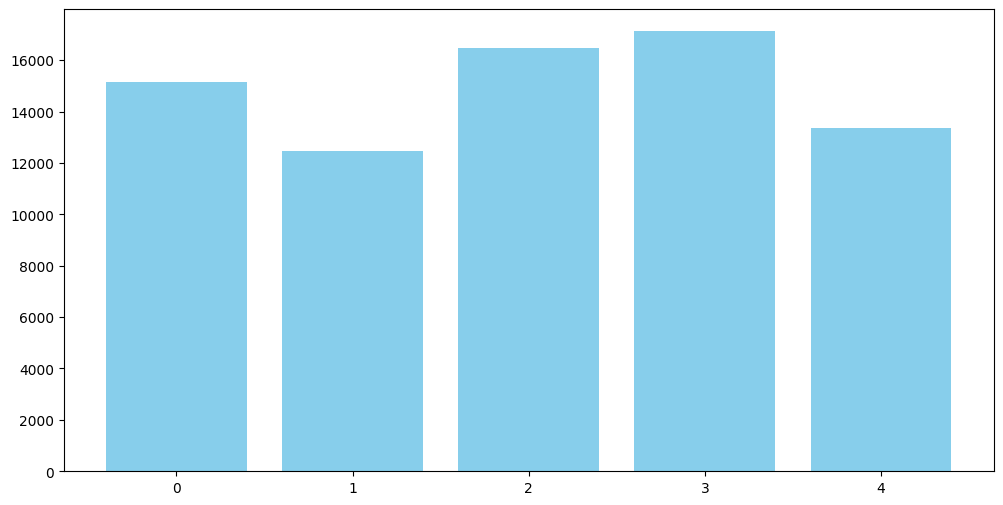

In [10]:
plt.figure(figsize=(12, 6))
bars = plt.bar(class_distribution.index, class_distribution.values, color='skyblue')

In [11]:
# 4. Outlier Detection and Removal
# Identify features (all columns except class_label)
feature_columns = df.columns[1:]

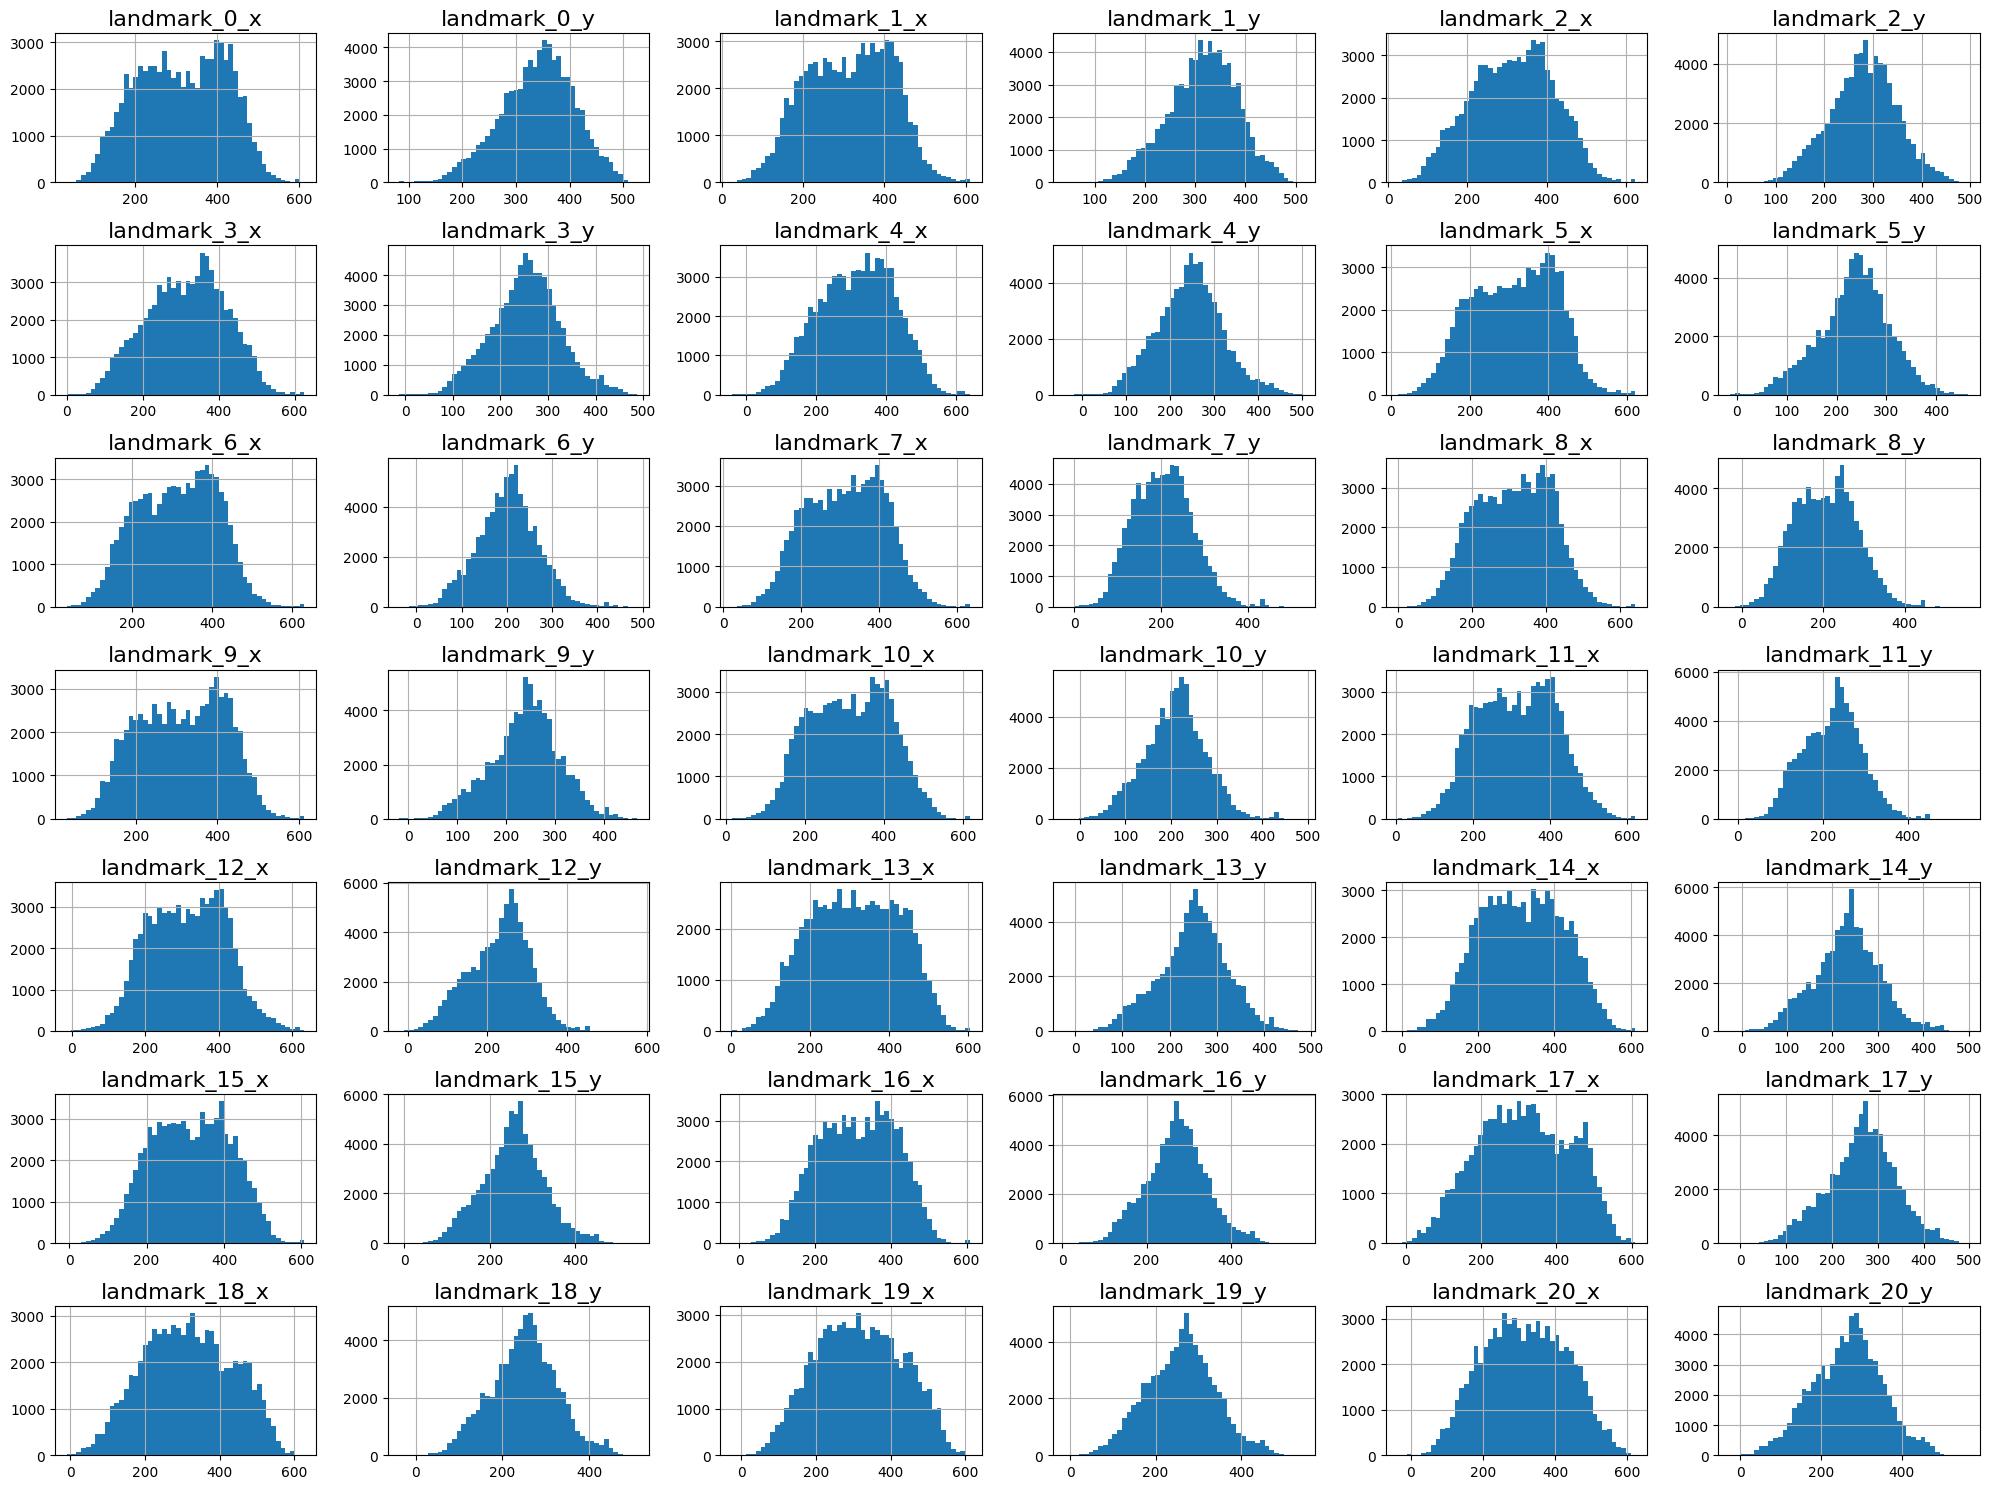

In [15]:
plt.rc('font', size=10)                  # Default font size for all text
plt.rc('axes', labelsize=16, titlesize=16)  # Font size for axes labels and titles
plt.rc('legend', fontsize=14)            # Font size for legend
plt.rc('xtick', labelsize=10)            # Font size for x-axis tick labels
plt.rc('ytick', labelsize=10)            # Font size for y-axis tick labels

# Plot histograms for each of the 42 columns in cleaned_df
# 'bins=50' means each histogram will have 50 bins
# 'figsize=(12, 8)' controls the size of the overall figure
df[feature_columns].hist(bins=50, figsize=(20, 15))  # Adjusted size to better fit 42 plots

# Display the plots
plt.tight_layout()  # Prevent overlap between subplots
plt.show()

In [14]:
# Calculate z-scores for outlier detection
print("\nDetecting outliers using z-scores...")
df_z = df.copy()
df_z[feature_columns + '_zscore'] = df[feature_columns].apply(zscore)


Detecting outliers using z-scores...


In [15]:
# Identify outliers (z-score > 3 or < -3)
outlier_columns = [col + '_zscore' for col in feature_columns]
outlier_mask = (df_z[outlier_columns] > 3.0) | (df_z[outlier_columns] < -3.0)
outliers_count = outlier_mask.any(axis=1).sum()
print(f"Found {outliers_count} samples with outliers (z-score beyond ±3)")

Found 971 samples with outliers (z-score beyond ±3)


In [16]:
# Remove outliers
df_clean = df[~outlier_mask.any(axis=1)]
print(f"Shape after outlier removal: {df_clean.shape}")

Shape after outlier removal: (73581, 43)


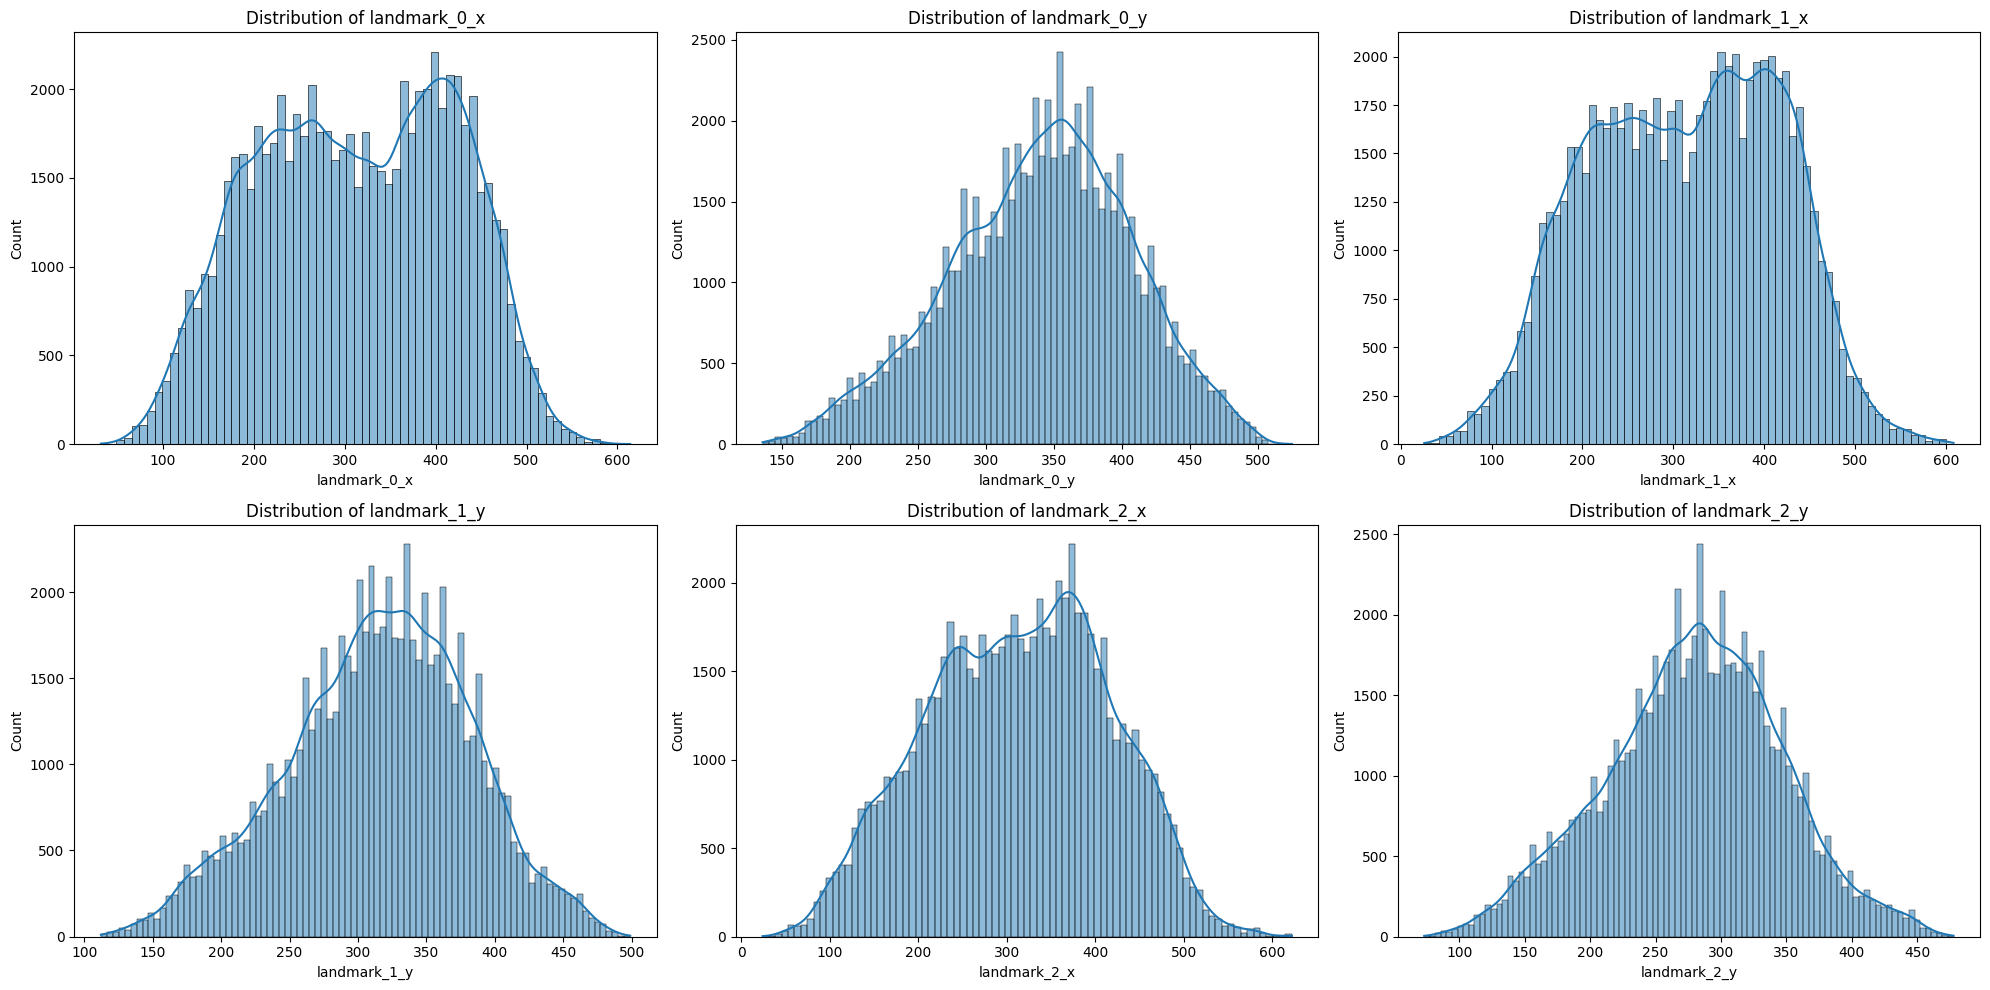

In [17]:
# 5. Visualize Data Distribution (Before Scaling)
plt.figure(figsize=(20, 10))
for i, col in enumerate(feature_columns[:6]):  # Show first 6 features as example
    plt.subplot(2, 3, i+1)
    sns.histplot(df_clean[col], kde=True)
    plt.title(f"Distribution of {col}")
plt.tight_layout()
plt.savefig('feature_distributions.png')
plt.show()
plt.close()

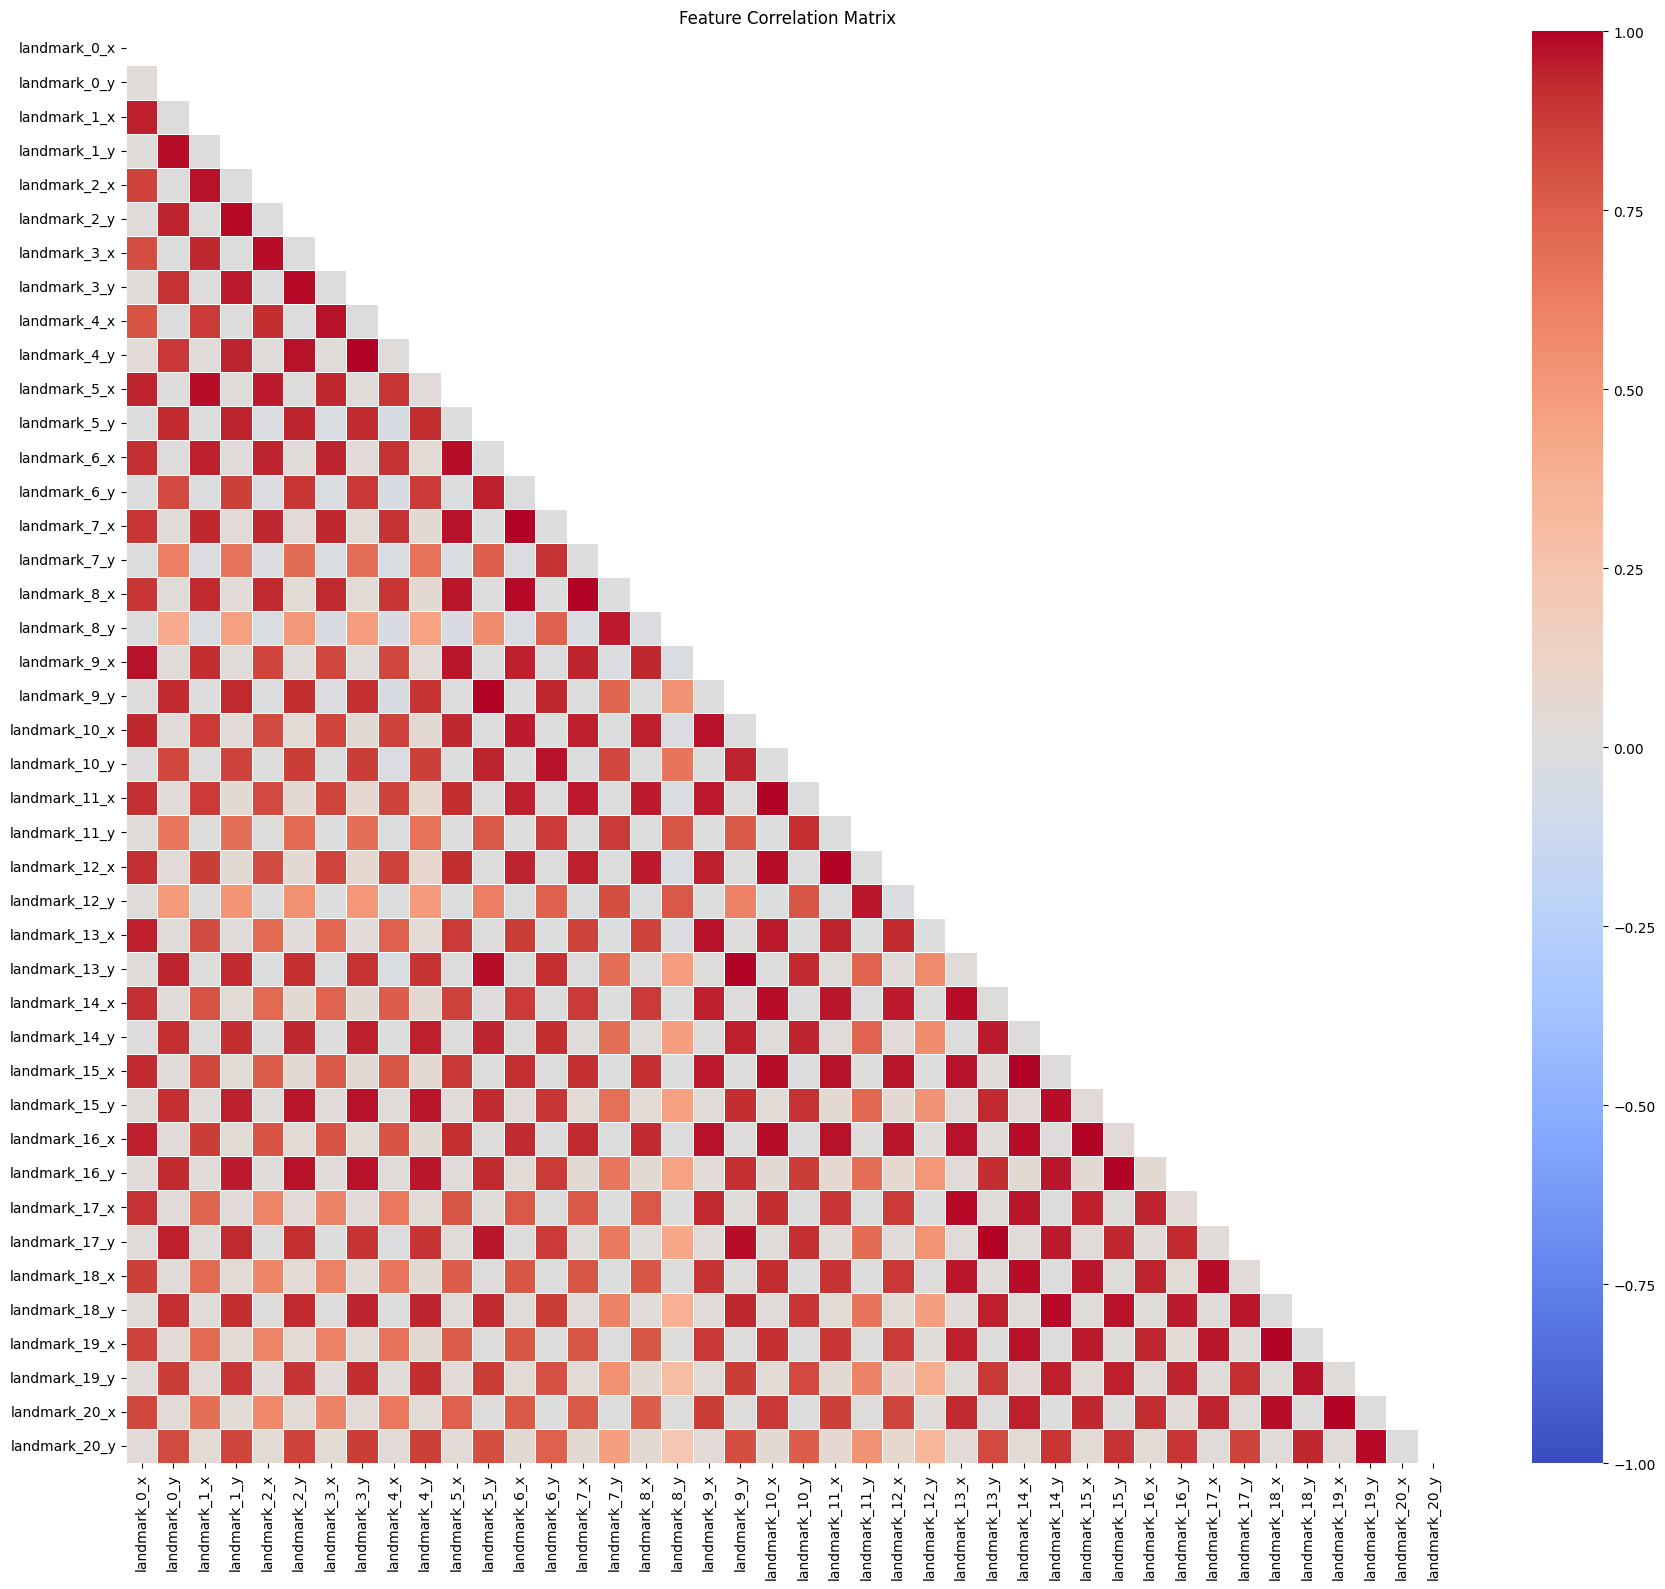

In [18]:
# 6. Feature Correlation Analysis
plt.figure(figsize=(18, 16))
corr_matrix = df_clean[feature_columns].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=False, cmap='coolwarm', 
            vmin=-1, vmax=1, linewidths=0.5)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.savefig('correlation_matrix.png')
plt.show()
plt.close()

In [19]:
# 7. Identify Highly Correlated Features
high_corr_threshold = 0.9
high_corr_pairs = []

for i in range(len(feature_columns)):
    for j in range(i+1, len(feature_columns)):
        if abs(corr_matrix.iloc[i, j]) > high_corr_threshold:
            high_corr_pairs.append((feature_columns[i], feature_columns[j], corr_matrix.iloc[i, j]))

print(f"\nHighly correlated feature pairs (correlation > {high_corr_threshold}):")
if high_corr_pairs:
    for pair in high_corr_pairs[:10]:  # Show first 10 pairs
        print(f"{pair[0]} and {pair[1]}: {pair[2]:.4f}")
    if len(high_corr_pairs) > 10:
        print(f"...and {len(high_corr_pairs) - 10} more pairs")
else:
    print("No highly correlated feature pairs found.")


Highly correlated feature pairs (correlation > 0.9):
landmark_0_x and landmark_1_x: 0.9476
landmark_0_x and landmark_5_x: 0.9452
landmark_0_x and landmark_6_x: 0.9102
landmark_0_x and landmark_9_x: 0.9733
landmark_0_x and landmark_10_x: 0.9301
landmark_0_x and landmark_11_x: 0.9138
landmark_0_x and landmark_12_x: 0.9065
landmark_0_x and landmark_13_x: 0.9464
landmark_0_x and landmark_14_x: 0.9111
landmark_0_x and landmark_15_x: 0.9284
...and 208 more pairs


In [20]:
# 8. Normalize the Data
print("\nNormalizing features...")
# Split data into features and target
X = df_clean[feature_columns]
y = df_clean['class_label']


Normalizing features...


In [21]:
# Perform normalization (MinMaxScaler scales values between 0 and 1)
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=feature_columns)

In [22]:
# Add class labels back
df_normalized = pd.concat([pd.Series(y.values, name='class_label'), X_scaled_df], axis=1)

print("Sample of normalized data:")
print(df_normalized.head())

Sample of normalized data:
   class_label  landmark_0_x  landmark_0_y  landmark_1_x  landmark_1_y  \
0            0      0.695876      0.622108      0.766323      0.594315   
1            0      0.515464      0.329049      0.429553      0.289406   
2            0      0.701031      0.637532      0.769759      0.614987   
3            0      0.713058      0.331620      0.680412      0.338501   
4            0      0.627148      0.293059      0.553265      0.232558   

   landmark_2_x  landmark_2_y  landmark_3_x  landmark_3_y  landmark_4_x  ...  \
0      0.777592      0.570370      0.742857      0.543943      0.702875  ...   
1      0.376254      0.271605      0.364706      0.268409      0.402556  ...   
2      0.780936      0.592593      0.752941      0.562945      0.714058  ...   
3      0.645485      0.335802      0.626891      0.311164      0.607029  ...   
4      0.515050      0.207407      0.536134      0.197150      0.586262  ...   

   landmark_16_x  landmark_16_y  landmark_17_x 

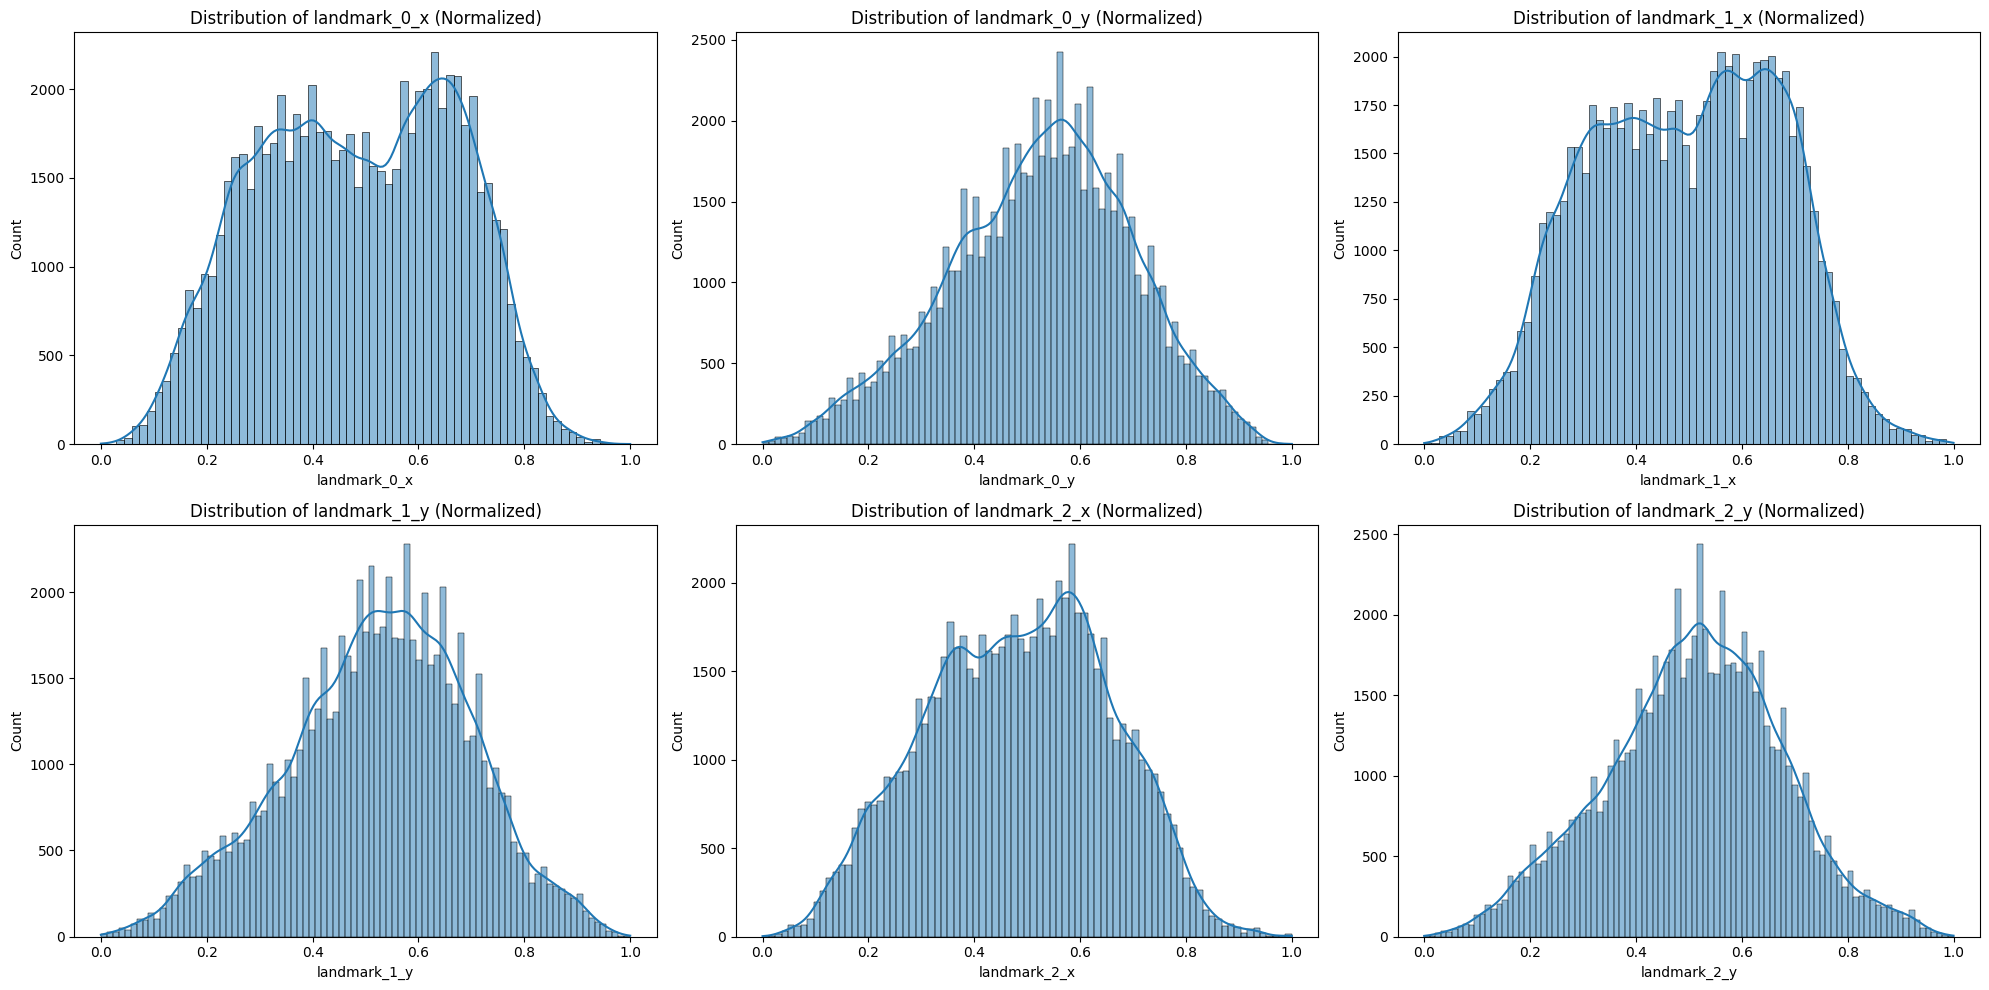

In [23]:
# 9. Visualize Data After Normalization
plt.figure(figsize=(20, 10))
for i, col in enumerate(feature_columns[:6]):  # Show first 6 features as example
    plt.subplot(2, 3, i+1)
    sns.histplot(df_normalized[col], kde=True)
    plt.title(f"Distribution of {col} (Normalized)")
plt.tight_layout()
plt.savefig('normalized_distributions.png')
plt.show()
plt.close()

In [24]:
df_normalized.to_csv('model/keypoint_classifier/gesture_3/cleaned_keypoint.csv', index=False)

In [25]:
# 10. Visualize Hand Landmarks for Each Class
def plot_hand_landmarks(df, class_label, num_samples=3):
    # Filter dataframe for the specific class
    class_df = df[df['class_label'] == class_label]
    
    # Select random samples (up to num_samples)
    samples = class_df.sample(min(num_samples, len(class_df)))
    
    fig, axes = plt.subplots(1, len(samples), figsize=(5*len(samples), 5))
    if len(samples) == 1:
        axes = [axes]  # Make axes iterable if only one sample
    
    for i, (_, sample) in enumerate(samples.iterrows()):
        # Extract x and y coordinates
        x_coords = [sample[f'landmark_{j}_x'] for j in range(21)]
        y_coords = [sample[f'landmark_{j}_y'] for j in range(21)]
        
        # Plot the landmarks
        axes[i].scatter(x_coords, y_coords, color='blue', s=30)
        
        # Connect landmarks to visualize hand structure
        # Define connections between landmarks based on MediaPipe hand topology
        connections = [
            (0, 1), (1, 2), (2, 3), (3, 4),  # Thumb
            (0, 5), (5, 6), (6, 7), (7, 8),  # Index finger
            (0, 9), (9, 10), (10, 11), (11, 12),  # Middle finger
            (0, 13), (13, 14), (14, 15), (15, 16),  # Ring finger
            (0, 17), (17, 18), (18, 19), (19, 20)  # Pinky
        ]
        
        for start, end in connections:
            axes[i].plot([x_coords[start], x_coords[end]], 
                         [y_coords[start], y_coords[end]], 'r-')
        
        axes[i].set_title(f'Class {class_label} - Sample {i+1}')
        axes[i].set_xlim(0, 1)
        axes[i].set_ylim(0, 1)
        axes[i].invert_yaxis()  # Invert y-axis to match MediaPipe coordinate system
    
    plt.suptitle(f'Hand Landmarks for Class {class_label}')
    plt.tight_layout()
    return fig

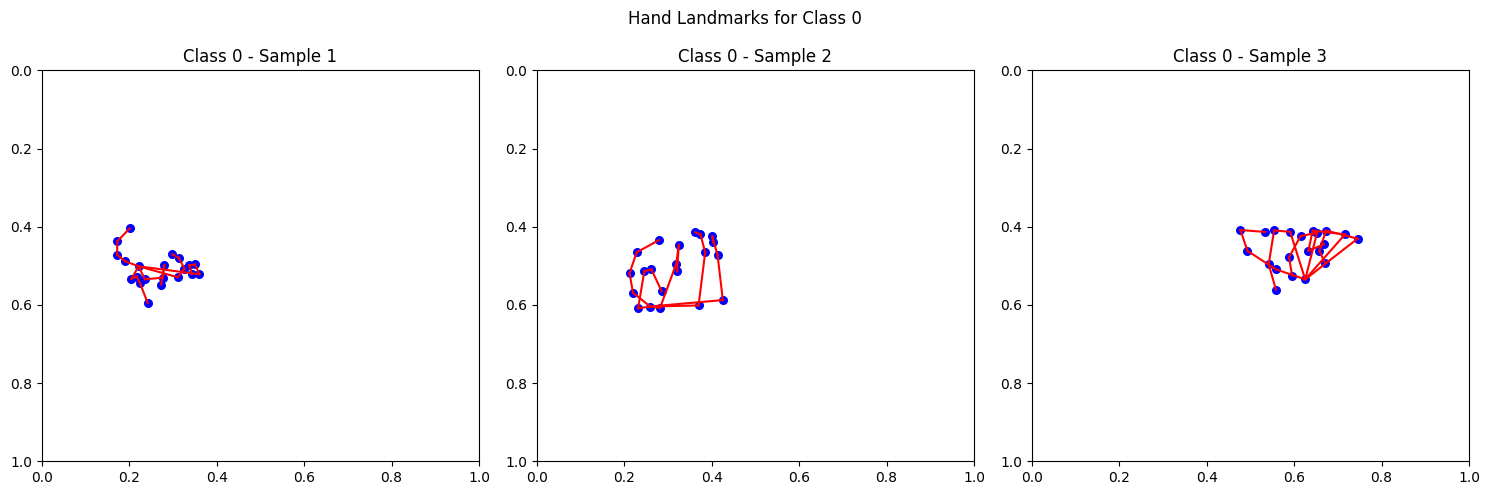

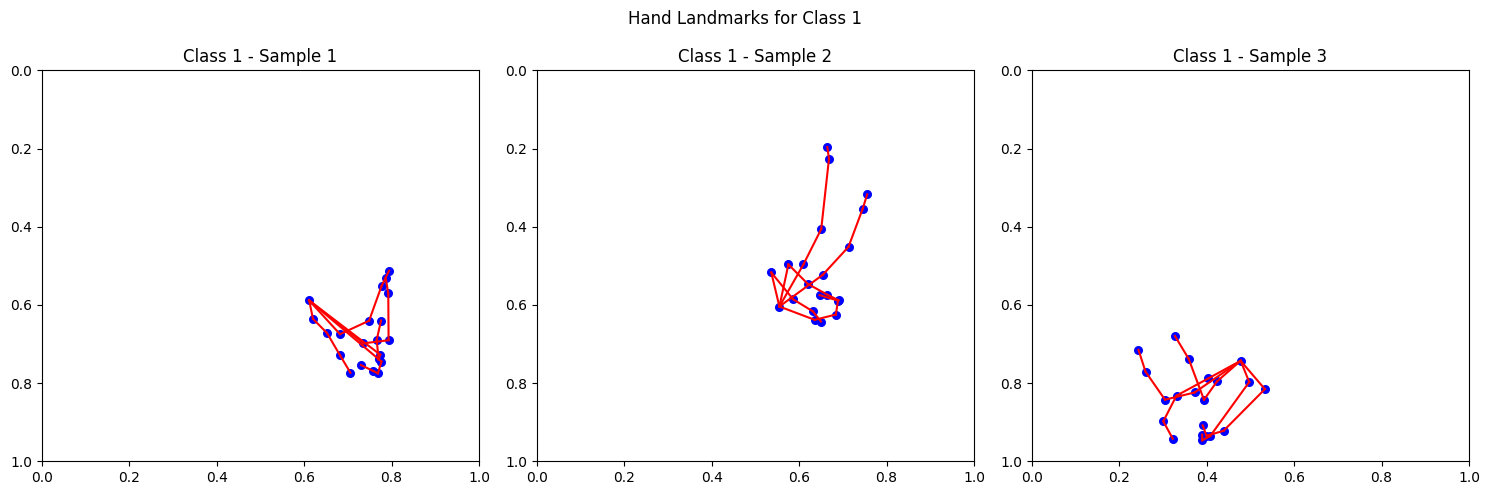

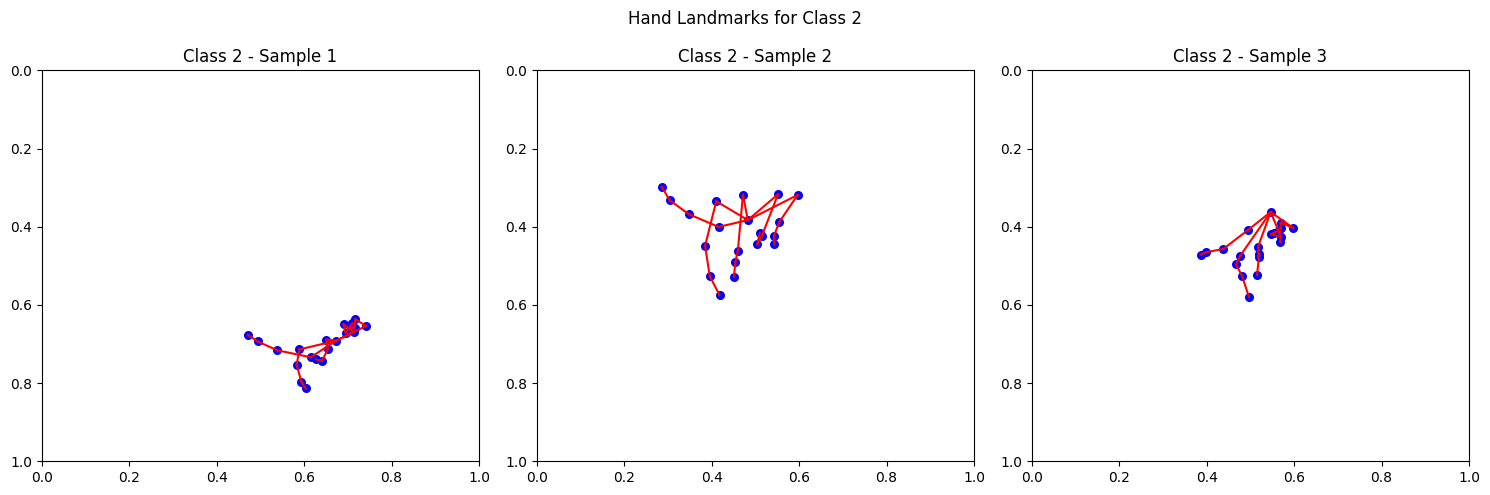

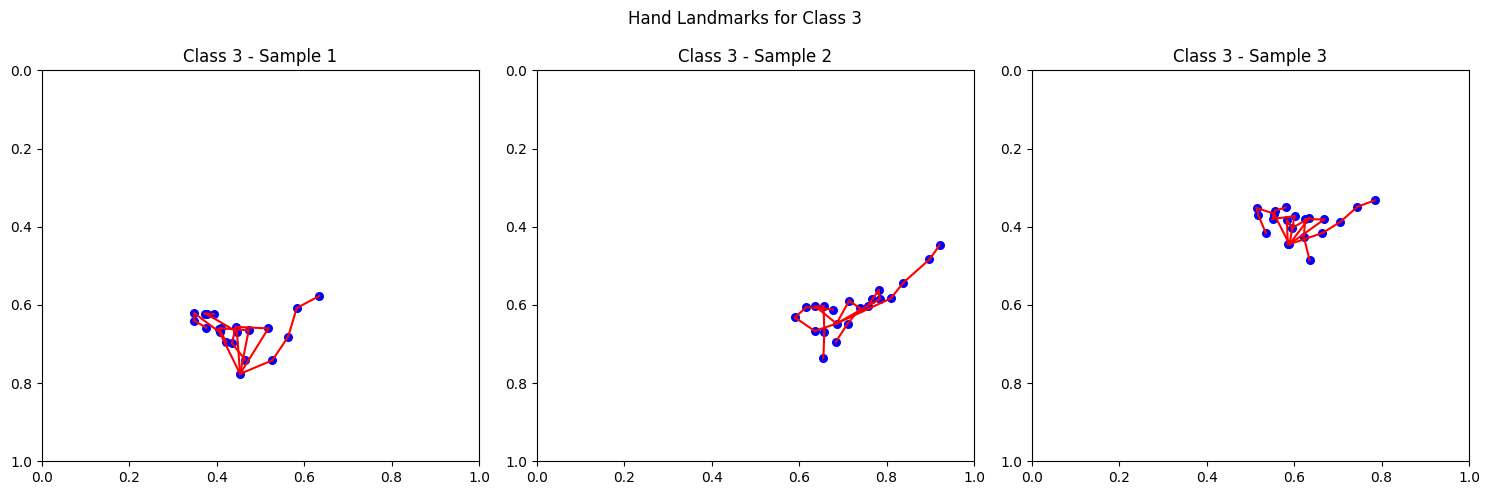

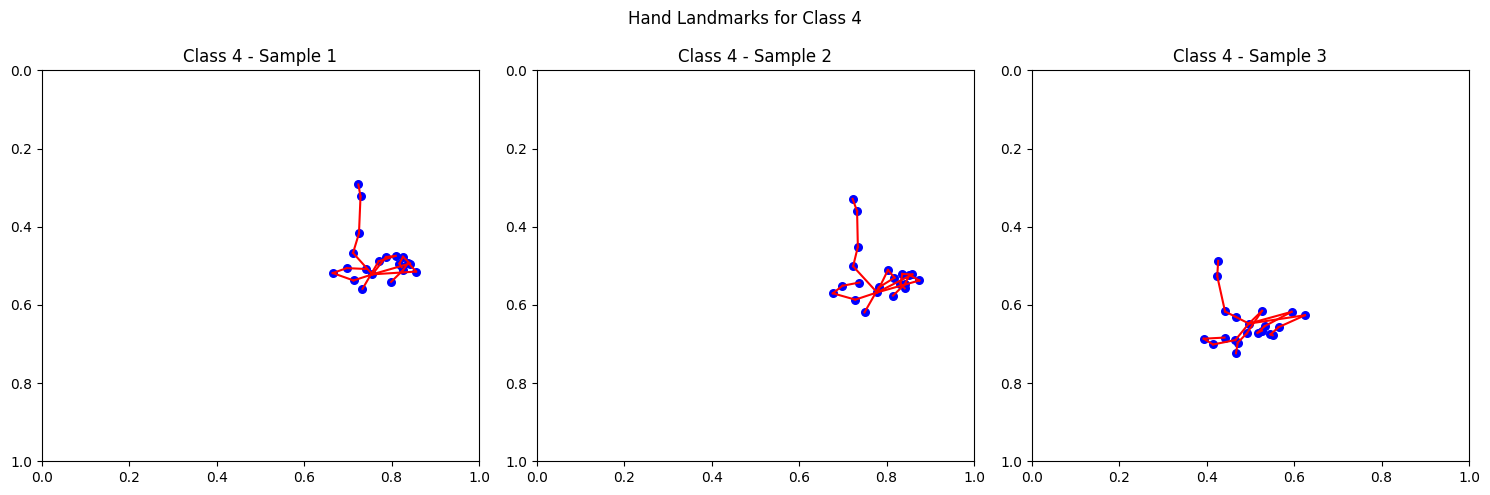

In [26]:
# Plot examples for each class
for class_label in sorted(df_normalized['class_label'].unique()):
    class_name = CONSTANT.getClassNameByIndex(class_label)
    fig = plot_hand_landmarks(df_normalized, class_label)
    plt.savefig(f'class_{class_name}_landmarks.png')
    plt.show()
    plt.close(fig)

In [27]:
# 11. Dimensionality Reduction with PCA
print("\nPerforming PCA for dimensionality reduction...")
pca = PCA()
X_pca = pca.fit_transform(X_scaled)



Performing PCA for dimensionality reduction...


In [28]:
# Calculate explained variance
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

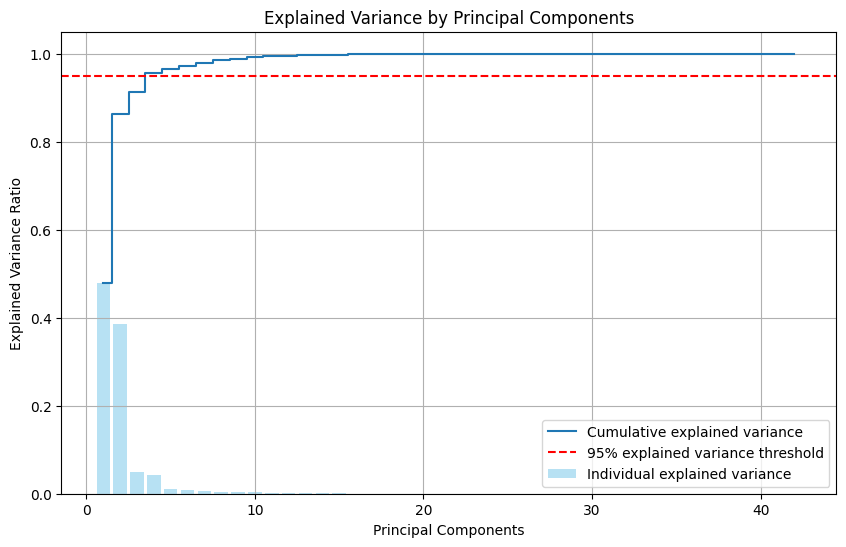

In [29]:
# Plot explained variance
plt.figure(figsize=(10, 6))
plt.bar(range(1, len(explained_variance) + 1), explained_variance, alpha=0.6, color='skyblue', label='Individual explained variance')
plt.step(range(1, len(cumulative_variance) + 1), cumulative_variance, where='mid', label='Cumulative explained variance')
plt.axhline(y=0.95, color='r', linestyle='--', label='95% explained variance threshold')
plt.xlabel('Principal Components')
plt.ylabel('Explained Variance Ratio')
plt.title('Explained Variance by Principal Components')
plt.legend()
plt.grid(True)
plt.savefig('pca_explained_variance.png')
plt.show()
plt.close()

In [30]:
# Find number of components needed for 95% variance
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1
print(f"Number of principal components needed for 95% variance: {n_components_95}")

Number of principal components needed for 95% variance: 4


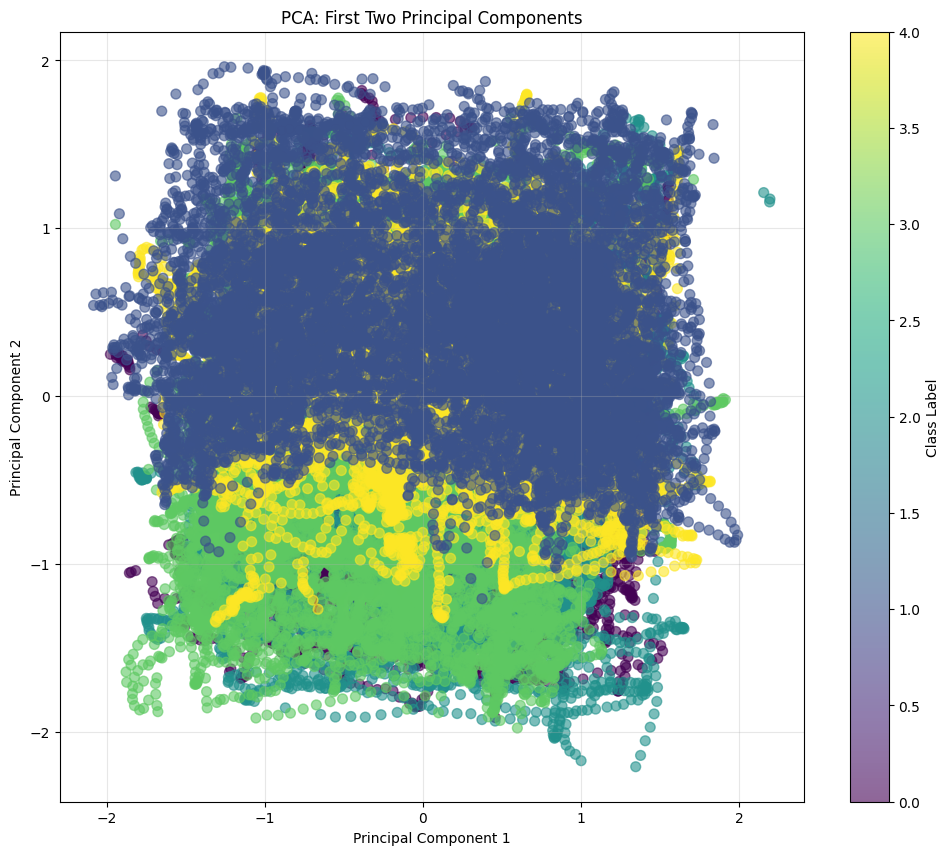

In [31]:
# Visualize first two principal components
plt.figure(figsize=(12, 10))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis', alpha=0.6, s=50)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA: First Two Principal Components')
plt.colorbar(scatter, label='Class Label')
plt.grid(True, alpha=0.3)
plt.savefig('pca_visualization.png')
plt.show()
plt.close()